# 15.3.2 伴随跳跃与反向重建的边界

## 学习目标与先修知识

推导多时刻观测（observation）的伴随跳跃和参数（parameter）梯度（gradient），比较离散反传与反向重建。

先修：15.3.1 前向灵敏度（forward sensitivity）；积分与分部积分的直觉。

## 具体问题

损失只在若干观测时刻发生。伴随变量从末时刻向前走时，经过每个观测时刻应该如何更新？若倒着数值积分状态（state），会精确回到初值（initial condition）吗？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
x0,k=2.,.7;obs=[(1.,.9),(2.,.45)];print("直接从解析解算的损失：",sum(.5*(x0*np.exp(-k*t)-y)**2 for t,y in obs))

直接从解析解算的损失： 0.0052732387616659295


## 模型假设

右端平滑且初态、观测时刻固定；损失 $J=\frac12\sum_j[x(t_j)-y_j]^2$。本节的连续伴随推导针对该连续问题；离散反传针对给定 Euler 程序。反向积分状态不是代数求逆，误差需要单独核验。

## 数学解释与推导

定义伴随 $\lambda$，在观测时刻之间满足 $\lambda'=-f_x^\mathsf T\lambda=k\lambda$，终点之后为零。跨越观测 $t_j$ 向后时，$\lambda(t_j^-)=\lambda(t_j^+)+x(t_j)-y_j$。连续参数梯度为 $\partial_kJ=\int_0^T\lambda(t)f_k\,dt=-\int_0^T\lambda(t)x(t)\,dt$。对每个观测贡献积分，得到 $\sum_j(x_j-y_j)(-t_jx_j)$，与解析解（analytical solution）相同。固定网格的离散反传则按 $\lambda_n=(1-kh)\lambda_{n+1}+r_n$ 反向累计，梯度加上 $-h\lambda_{n+1}x_n$。两种路线先各自核验，再比较网格细化；在观测点遗漏跳跃会得到错误梯度。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def clearance_exact(x0, k, times):
    return [float(x0*math.exp(-k*t)) for t in times]


def euler_forward_sensitivity(x0, k, h, steps):
    """Return state and dx/dk for the *discretized* Euler program."""
    states, sensitivity = [float(x0)], [0.]
    for _ in range(steps):
        x, s = states[-1], sensitivity[-1]
        states.append((1-k*h)*x)
        sensitivity.append((1-k*h)*s-h*x)
    return states, sensitivity


def continuous_loss_gradient(x0, k, observations):
    """Exact continuous-observation objective and its derivative."""
    loss, gradient = 0., 0.
    for t, y in observations:
        x = x0*math.exp(-k*t)
        residual = x-y
        loss += .5*residual*residual
        gradient -= t*x*residual
    return loss, gradient


def adjoint_midpoint_gradient(x0, k, observations, subdivisions):
    """Piecewise midpoint integral with the correct observation jumps."""
    rows = sorted((float(t), float(y)) for t, y in observations)
    gradient = 0.
    left = 0.
    for right, _ in rows:
        if right <= left:
            continue
        h = (right-left)/subdivisions
        for j in range(subdivisions):
            t = left+(j+.5)*h
            state = x0*math.exp(-k*t)
            # A residual at t_j contributes only before that observation.
            lam = sum((x0*math.exp(-k*tj)-y)*math.exp(-k*(tj-t))
                      for tj,y in rows if tj >= right)
            gradient -= h*lam*state
        left = right
    return gradient


def euler_reverse_gradient(x0, k, h, observations):
    """Grid-indexed observations; reverse accumulation differentiates Euler."""
    steps = max(int(i) for i in observations)
    states, _ = euler_forward_sensitivity(x0, k, h, steps)
    lam, gradient = 0., 0.
    for i in range(steps, -1, -1):
        lam += states[i]-observations[i] if i in observations else 0.
        if i:
            gradient -= h*states[i-1]*lam
            lam *= (1-k*h)
    return gradient


def reverse_reconstruct(x0, k, h, steps):
    x = float(x0)
    for _ in range(steps):
        x = x-h*k*x
    terminal = x
    for _ in range(steps):
        x = x+h*k*x
    return terminal, x

## 对照实验

改变已声明的条件并比较曲线与数值。

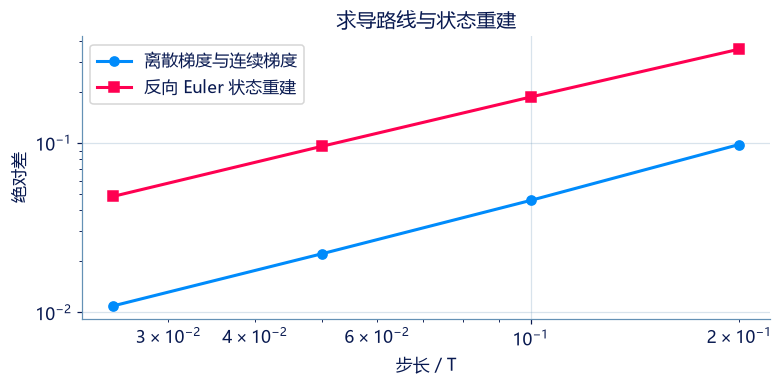

连续伴随积分 / 解析梯度： -0.1351402748487409 -0.13514027484874086
训练估计的修正幅度： 0.15 ；新初值线性/修正 RMSE： 0.08354992277509811 0.0


In [4]:
x0,k=2.,.7;obs=[(1.,.9),(2.,.45)];exact=continuous_loss_gradient(x0,k,obs)[1];adj=adjoint_midpoint_gradient(x0,k,obs,8)
rows=[]
for h in [.2,.1,.05,.025]:
    integer_obs={round(t/h):y for t,y in obs};disc=euler_reverse_gradient(x0,k,h,integer_obs);recovered=reverse_reconstruct(x0,k,h,round(2/h))[1];rows.append((h,abs(disc-exact),abs(recovered-x0)))
fig,ax=plt.subplots(figsize=(7,3.4));ax.loglog([r[0] for r in rows],[r[1] for r in rows],"o-",label="离散梯度与连续梯度",color=BLUE);ax.loglog([r[0] for r in rows],[r[2] for r in rows],"s-",label="反向 Euler 状态重建",color=PINK);ax.set(xlabel="步长 / T",ylabel="绝对差",title="求导路线与状态重建");ax.legend();ax.grid(alpha=.25);plt.show()
print("连续伴随积分 / 解析梯度：",adj,exact)

# A one-unit smooth correction is learnable in the ODE right-hand side.
# The continuous model is approximated with the same fixed fine step for
# training and held-out prediction; the linear baseline shares that step.
def nonlinear_trajectory(initial,theta,steps,step=.01):
    x=float(initial);path=[x]
    for _ in range(steps):
        x+=step*(-.7*x-theta*np.tanh(x))
        path.append(x)
    return np.asarray(path)
reference=nonlinear_trajectory(1.5,.15,200)
observed=reference[[50,100,150]]
theta_grid=np.linspace(0.,.3,61)
losses=[np.mean((nonlinear_trajectory(1.5,float(theta),200)[[50,100,150]]-observed)**2)
        for theta in theta_grid]
fitted=float(theta_grid[np.argmin(losses)])
new_truth=nonlinear_trajectory(2.,.15,200)
new_linear=nonlinear_trajectory(2.,0.,200)
new_learned=nonlinear_trajectory(2.,fitted,200)
print("训练估计的修正幅度：",fitted,
      "；新初值线性/修正 RMSE：",
      np.sqrt(np.mean((new_linear-new_truth)**2)),
      np.sqrt(np.mean((new_learned-new_truth)**2)))


## 结果解释

本标量线性例中每个观测区间的伴随与状态乘积恰为常数，因此中点积分已经精确；一般非线性右端不具备此便利。反向 Euler 重建并非正向 Euler 的精确逆，尤其不能把重建误差混入“真实连续伴随”的论断。 固定 tanh 形状的右端只学习一个修正幅度；这里用有界网格搜索展示拟合，再以新初值检查预测。它不是原论文完整架构，不能把此人工例当作一般 Neural ODE 性能。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
np.testing.assert_allclose(adj,exact,atol=1e-12)
for h in [.2,.1]:
    targets={round(t/h):y for t,y in obs};numeric=euler_reverse_gradient(x0,k,h,targets)
    eps=1e-6
    def discrete_loss(rate):
        values=euler_forward_sensitivity(x0,rate,h,round(2/h))[0]
        return .5*sum((values[i]-y)**2 for i,y in targets.items())
    np.testing.assert_allclose(numeric,(discrete_loss(k+eps)-discrete_loss(k-eps))/(2*eps),atol=1e-9)
assert rows[-1][1]<rows[0][1]
print("连续解析、跳跃积分与离散程序中心差分分别核验通过。")
assert abs(fitted-.15)<1e-12
assert np.sqrt(np.mean((new_learned-new_truth)**2)) < np.sqrt(np.mean((new_linear-new_truth)**2))
np.testing.assert_allclose(nonlinear_trajectory(1.,0.,1),[1.,.993])
print("非线性修正训练与零修正解析一步极限核验通过。")


连续解析、跳跃积分与离散程序中心差分分别核验通过。
非线性修正训练与零修正解析一步极限核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：观测时刻的伴随跳跃

J=1/2 Σ(x(tj)-yj)^2；向后穿越 tj 时应如何更新 λ？

- **A.** 忽略该时刻，因为观测（observation）只在离散点。
- **B.** 乘以时间步长（time step）后再加入残差（residual）。
- **C.** 加入 x(tj)-yj。
- **D.** 永远将 λ 设为零。

[作答：观测时刻的伴随跳跃](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p15-adjoint-jump)

### 第 2 题 · 单项选择题：反向状态重建

前向 Euler 后把 ODE 反向再用 Euler 积分，哪项成立？

- **A.** 一定精确回到初态。
- **B.** 任何稳定模型（model）都能无误差逆向求解。
- **C.** 反向误差只来自观测（observation）噪声。
- **D.** 要单独检验重建误差，不能把它当作连续伴随的数学恒等式。

[作答：反向状态重建](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p15-reverse-state)

### 第 3 题 · Python 计算题：固定观测时刻的连续损失梯度

按解析指数解计算多时刻半平方损失及其对 k 的导数（derivative）。

**函数与代码模板**

```python
def solve(
    x0: float,
    k: float,
    observations: list[list[float]],
) -> tuple[float, float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 固定初态。 | U |
| `k` | `float` | 消除系数。 | 1/T |
| `observations` | `list[list[float]]` | 每行 [时刻,观测（observation）总量]。 | T、U |

**返回值**

按以下顺序返回元组：(loss, gradient)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `loss` | `float` | 观测半平方损失之和。 | U² |
| `gradient` | `float` | 该连续损失对 k 的导数。 | U²·T |

**计算规则**

在每个 [t,y] 上计算 x=x0*exp(-k*t)、r=x-y；损失 Σr²/2，梯度（gradient） Σr*(-t*x)。

**约束与边界**

- x0≥0，k≥0；观测时刻非负，观测不超过 20 项。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 固定初态。 | 2 | U |
| k | 消除系数。 | 0 | 1/T |
| observations | 每行 [时刻,观测（observation）总量]。 | [[0.0, 2.0], [1.0, 1.0]] | T、U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 2.0
k = 0.0
observations = [[0.0, 2.0], [1.0, 1.0]]

result = solve(x0, k, observations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| loss | 观测半平方损失之和。 | 0.5 | U² |
| gradient | 该连续损失对 k 的导数。 | -2 | U²·T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.5, -2.0)
```

**样例解释**

首例 t=0 的残差（residual）为0；t=1 的预测为2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：固定观测时刻的连续损失梯度](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p15-continuous-gradient)

### 第 4 题 · Python 计算题：带观测跳跃的离散梯度

对固定 Euler 网格上的观测（observation）损失求 k 梯度（gradient）；观测在给定整数网格点。

**函数与代码模板**

```python
def solve(
    x0: float,
    k: float,
    h: float,
    observation_indices: list[int],
    targets: list[float],
) -> float:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 固定初态。 | U |
| `k` | `float` | 消除系数。 | 1/T |
| `h` | `float` | Euler 步长。 | T |
| `observation_indices` | `list[int]` | 各观测的整数网格索引。 | 步 |
| `targets` | `list[float]` | 与索引对应的观测总量。 | U |

**返回值**

直接返回 gradient（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `gradient` | `float` | 离散程序的观测损失对 k 的导数（derivative）。 | U²·T |

**计算规则**

先 Euler 推进到最大观测索引；按每点半平方损失反向传播（backpropagation），返回该离散程序对 k 的梯度。观测索引互不重复。

**约束与边界**

- x0≥0，k≥0，h>0，k*h<1；索引非负互异且不超过100，至少有一条观测，索引和目标两个列表等长且非空。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 固定初态。 | 2 | U |
| k | 消除系数。 | 0.5 | 1/T |
| h | Euler 步长。 | 0.2 | T |
| observation_indices | 各观测的整数网格索引。 | [1, 2] | 步 |
| targets | 与索引对应的观测总量。 | [1.8, 1.5] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 2.0
k = 0.5
h = 0.2
observation_indices = [1, 2]
targets = [1.8, 1.5]

result = solve(x0, k, h, observation_indices, targets)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| gradient | 离散程序的观测损失对 k 的导数（derivative）。 | -0.0864 | U²·T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = -0.08640000000000009
```

**样例解释**

经过观测网格点时，先把状态（state）残差（residual）加进伴随，再向前传播。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：带观测跳跃的离散梯度](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p15-discrete-adjoint)

**进一步阅读**

[Chen 等](https://papers.nips.cc/paper_files/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf)提出伴随训练路线；此处单独暴露观测跳跃与数值重建误差。